Estimated threshold (Otsu): 124.0


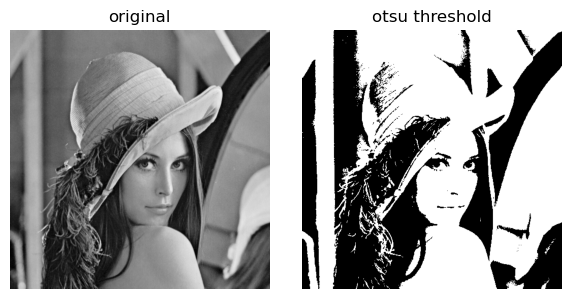

In [1]:
# p97 Binarization using Otsu algorithm
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('Lena.png', cv2.IMREAD_GRAYSCALE)
otsu_thr, otsu_mask = cv2.threshold(image, -1, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
print('Estimated threshold (Otsu):', otsu_thr)

plt.figure(figsize=(6, 3))
plt.subplot(121)
plt.axis('off')
plt.title('original')
plt.imshow(image, cmap='gray')
plt.subplot(122)
plt.axis('off')
plt.title('otsu threshold')
plt.imshow(otsu_mask, cmap='gray')
plt.tight_layout()
plt.show()


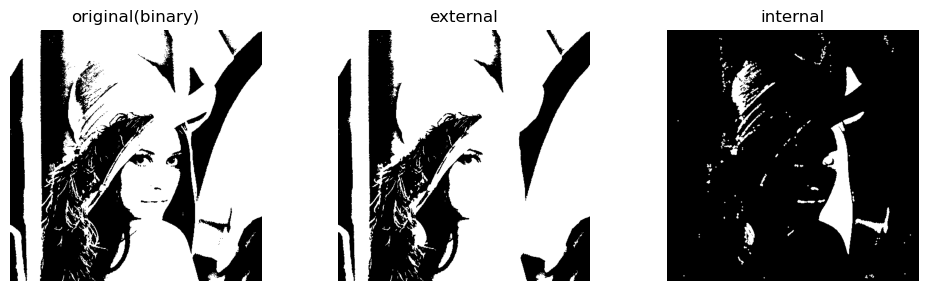

In [2]:
# p98 Finding external and internal contours
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('Lena.png', cv2.IMREAD_GRAYSCALE)
_, image = cv2.threshold(image, -1, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

contours, hierarchy = cv2.findContours(image, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

image_external = np.zeros(image.shape, image.dtype)
for i in range(len(contours)):
    if hierarchy[0][i][3] == -1:
        cv2.drawContours(image_external, contours, i, 255, -1)

image_internal = np.zeros(image.shape, image.dtype)
for i in range(len(contours)):
    if hierarchy[0][i][3] != -1:
        cv2.drawContours(image_internal, contours, i, 255, -1)

plt.figure(figsize=(10, 3))
plt.subplot(131)
plt.axis('off')
plt.title('original(binary)')
plt.imshow(image, cmap='gray')
plt.subplot(132)
plt.axis('off')
plt.title('external')
plt.imshow(image_external, cmap='gray')
plt.subplot(133)
plt.axis('off')
plt.title('internal')
plt.imshow(image_internal, cmap='gray')
plt.tight_layout()
plt.show()



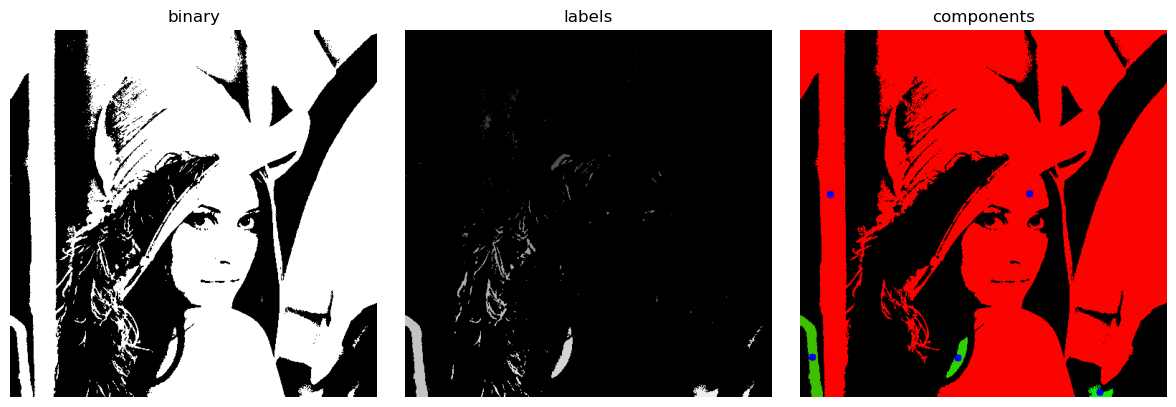

In [3]:
# p99 Extracting connected component
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Lena.png', cv2.IMREAD_GRAYSCALE)
_, bw = cv2.threshold(img, -1, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

connectivity = 8
num_labels, labelmap = cv2.connectedComponents(bw, connectivity, cv2.CV_32S)
img_cc = np.hstack((bw, (labelmap.astype(np.float32) / max(num_labels - 1, 1)) * 255)).astype(np.uint8)

output = cv2.connectedComponentsWithStats(bw, connectivity, cv2.CV_32S)
num_labels, labelmap, stats, centers = output

colored = np.full((bw.shape[0], bw.shape[1], 3), 0, np.uint8)
for l in range(1, num_labels):
    if stats[l][4] > 200:
        colored[labelmap == l] = (0, 255 * l / num_labels, 255 * (num_labels - l) / num_labels)
        cv2.circle(colored, (int(centers[l][0]), int(centers[l][1])), 5, (255, 0, 0), cv2.FILLED)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.axis('off')
plt.title('binary')
plt.imshow(bw, cmap='gray')
plt.subplot(132)
plt.axis('off')
plt.title('labels')
plt.imshow(img_cc[:, bw.shape[1]:], cmap='gray')
plt.subplot(133)
plt.axis('off')
plt.title('components')
plt.imshow(cv2.cvtColor(colored, cv2.COLOR_BGR2RGB))
plt.tight_layout()
plt.show()



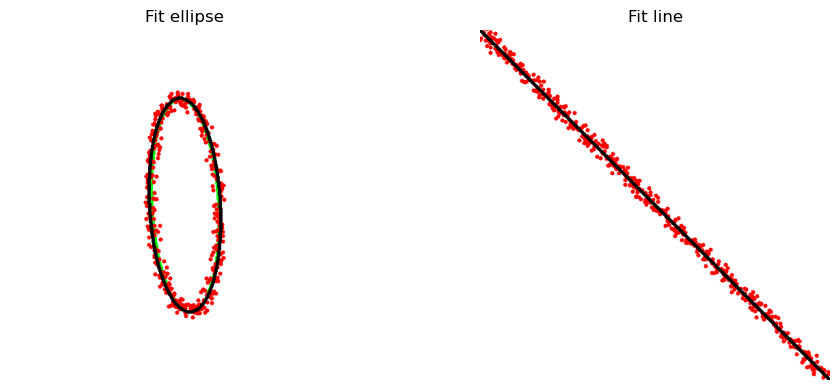

In [6]:
# p100 Fitting lines and circles
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

img = np.full((512, 512, 3), 255, np.uint8)

axes = (int(256 * random.uniform(0, 1)), int(256 * random.uniform(0, 1)))
angle = int(180 * random.uniform(0, 1))
center = (256, 256)

pts = cv2.ellipse2Poly(center, axes, angle, 0, 360, 1)
pts += np.random.uniform(-10, 10, pts.shape).astype(np.int32)

cv2.ellipse(img, center, axes, angle, 0, 360, (0, 255, 0), 3)
for pt in pts:
    cv2.circle(img, (int(pt[0]), int(pt[1])), 3, (0, 0, 255), -1)

ellipse = cv2.fitEllipse(pts)
cv2.ellipse(img, ellipse, (0, 0, 0), 3)

img2 = np.full((512, 512, 3), 255, np.uint8)
pts = np.arange(512).reshape(-1, 1)
pts = np.hstack((pts, pts))
pts += np.random.uniform(-10, 10, pts.shape).astype(np.int32)
cv2.line(img2, (0, 0), (512, 512), (0, 255, 0), 3)
for pt in pts:
    cv2.circle(img2, (int(pt[0]), int(pt[1])), 3, (0, 0, 255), -1)

# fitLine 반환값은 (1,) 배열이므로 스칼라로 변환
vx, vy, x, y = cv2.fitLine(pts, cv2.DIST_L2, 0, 0.01, 0.01).flatten()
y0 = int(y - x * vy / vx)
y1 = int((512 - x) * vy / vx + y)
cv2.line(img2, (0, y0), (512, y1), (0, 0, 0), 3)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.axis('off')
plt.title('Fit ellipse')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(122)
plt.axis('off')
plt.title('Fit line')
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.tight_layout()
plt.show()


In [7]:
# p101 Calculating image moments
import cv2
import numpy as np

image = np.zeros((480, 640), np.uint8)
cv2.ellipse(image, (320, 240), (200, 100), 0, 0, 360, 255, -1)

m = cv2.moments(image)
for name, val in m.items():
    print(name, '	', val)

print('Center X estimated:', m['m10'] / m['m00'])
print('Center Y estimated:', m['m01'] / m['m00'])


m00 	 16119315.0
m10 	 5158101240.0
m01 	 3868620810.0
m20 	 1812142855350.0
m11 	 1237939564800.0
m02 	 969157708320.0
m30 	 683285449618080.0
m21 	 434912202354750.0
m12 	 310125260718570.0
m03 	 252129278267070.0
mu20 	 161575917357.3161
mu11 	 -72.99898723709362
mu02 	 40692263506.429634
mu30 	 1687957749.2054534
mu21 	 -420182048.7201112
mu12 	 -422443285.18396664
mu03 	 105694127.73531105
nu20 	 0.0006218468887998857
nu11 	 -2.80946528674459e-13
nu02 	 0.0001566097093772906
nu30 	 1.61806184141218e-09
nu21 	 -4.027829131389309e-10
nu12 	 -4.049505150462041e-10
nu03 	 1.0131748560078178e-10
Center X estimated: 319.9950643063927
Center Y estimated: 239.999082467214


Area of contour is 0.00
Signed area of contour is 0.00
Signed area of contour is 0.00
Length of closed contour is 2.00
Length of open contour is 1.00
Convex status of contour is False
Convex status of its hull is False


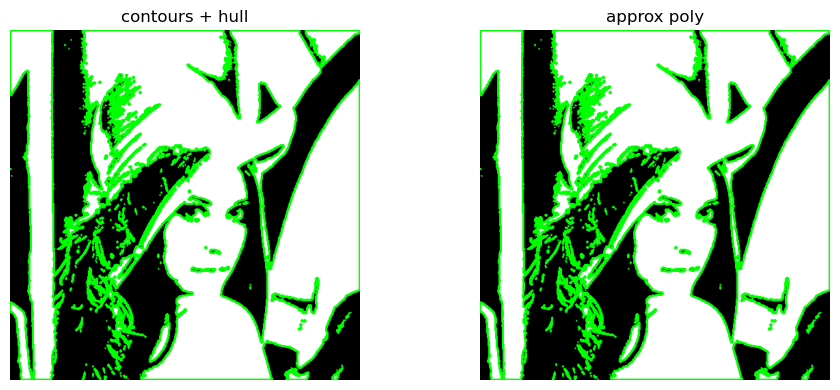

In [8]:
# p102 Working with curves
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Lena.png', cv2.IMREAD_GRAYSCALE)
_, img = cv2.threshold(img, -1, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

contours, hierarchy = cv2.findContours(img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(color, contours, -1, (0, 255, 0), 2)

contour = contours[0]
print('Area of contour is %.2f' % cv2.contourArea(contour))
print('Signed area of contour is %.2f' % cv2.contourArea(contour, True))
print('Signed area of contour is %.2f' % cv2.contourArea(contour[::-1], True))

print('Length of closed contour is %.2f' % cv2.arcLength(contour, True))
print('Length of open contour is %.2f' % cv2.arcLength(contour, False))

hull = cv2.convexHull(contour)
cv2.drawContours(color, [hull], -1, (0, 0, 255), 2)

print('Convex status of contour is %s' % cv2.isContourConvex(contour))
print('Convex status of its hull is %s' % cv2.isContourConvex(hull))

epsilon = 0.01 * cv2.arcLength(contour, True)
approx = cv2.approxPolyDP(contour, epsilon, True)
poly_img = color.copy()
cv2.drawContours(poly_img, [approx], -1, (255, 0, 255), 2)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.axis('off')
plt.title('contours + hull')
plt.imshow(cv2.cvtColor(color, cv2.COLOR_BGR2RGB))
plt.subplot(122)
plt.axis('off')
plt.title('approx poly')
plt.imshow(cv2.cvtColor(poly_img, cv2.COLOR_BGR2RGB))
plt.tight_layout()
plt.show()



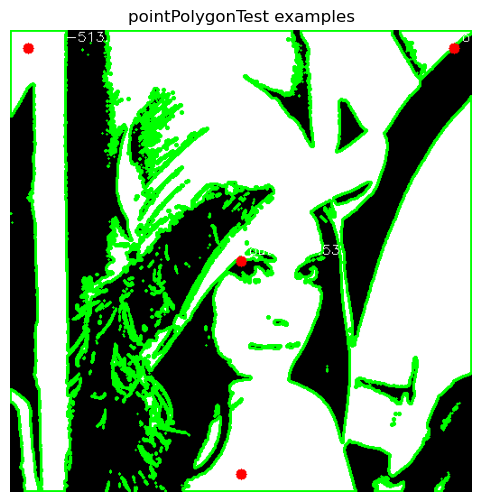

In [9]:
# p103 Checking the location of points (non-interactive)
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Lena.png', cv2.IMREAD_GRAYSCALE)
_, img = cv2.threshold(img, -1, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
contours, hierarchy = cv2.findContours(img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(color, contours, -1, (0, 255, 0), 2)

contour = contours[0]
h, w = img.shape

# 샘플 포인트 4개를 검사: 내부/외부/경계 근처/중앙
sample_points = [
    (w // 2, h // 2),
    (20, 20),
    (w // 2, h - 20),
    (w - 20, 20),
]

out = color.copy()
for (x, y) in sample_points:
    distance = cv2.pointPolygonTest(contour, (x, y), True)
    if distance > 0:
        pt_color = (0, 255, 0)   # inside
        label = f"in {distance:.2f}"
    elif distance < 0:
        pt_color = (0, 0, 255)   # outside
        label = f"out {distance:.2f}"
    else:
        pt_color = (128, 0, 128) # on boundary
        label = "on 0.00"

    cv2.circle(out, (x, y), 6, pt_color, -1)
    cv2.putText(out, label, (x + 8, y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

plt.figure(figsize=(8, 6))
plt.title('pointPolygonTest examples')
plt.axis('off')
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.show()




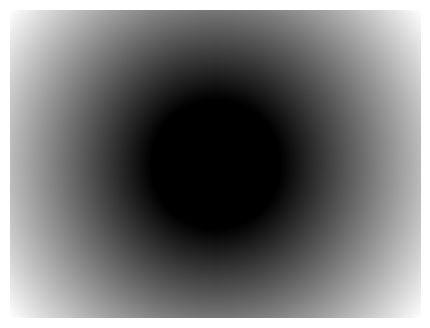

In [10]:
# p104 Computing distance to 2d point set
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = np.full((480, 640), 255, np.uint8)
cv2.circle(image, (320, 240), 100, 0, -1)

distmap = cv2.distanceTransform(image, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)

plt.figure(figsize=(6, 4))
plt.imshow(distmap, cmap='gray')
plt.axis('off')
plt.show()


In [12]:
# p105 Practice (Integrated): Otsu + External/Internal Contour + Connected Components + Distance Transform
import cv2
import numpy as np
import random
from pathlib import Path

# Try local video path first; if not found, fall back to webcam (0)
VIDEO_PATH = Path(r"C:\Users\admin\Desktop\VSCode\dataset\input.mp4")
cap = cv2.VideoCapture(str(VIDEO_PATH) if VIDEO_PATH.exists() else 0)

if not cap.isOpened():
    raise RuntimeError(f"Cannot open video source. Check file path: {VIDEO_PATH}")

print("[Keys] space: reshuffle 5 components, q or ESC: quit")

selected_labels = []
selected_colors = {}

# Show in a larger resizable window for readability
WIN_NAME = "p105 practice"
cv2.namedWindow(WIN_NAME, cv2.WINDOW_NORMAL)
cv2.resizeWindow(WIN_NAME, 1200, 700)


def put_text_box(img, text, org, scale=0.7, fg=(255, 255, 255), bg=(20, 20, 20), thickness=2):
    """High-contrast text box for readability"""
    (tw, th), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, scale, thickness)
    x, y = org
    cv2.rectangle(img, (x - 6, y - th - 8), (x + tw + 8, y + baseline + 6), bg, -1)
    cv2.putText(img, text, (x, y), cv2.FONT_HERSHEY_SIMPLEX, scale, (0, 0, 0), thickness + 2, cv2.LINE_AA)
    cv2.putText(img, text, (x, y), cv2.FONT_HERSHEY_SIMPLEX, scale, fg, thickness, cv2.LINE_AA)


def pick_labels_and_colors(valid_labels, k=5):
    picked = random.sample(valid_labels, min(k, len(valid_labels))) if valid_labels else []
    colors = {
        lb: (random.randint(70, 255), random.randint(70, 255), random.randint(70, 255))
        for lb in picked
    }
    return picked, colors


while True:
    ret, frame = cap.read()
    if not ret:
        # If file video reaches the end, rewind to frame 0
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        ret, frame = cap.read()
        if not ret:
            break

    # Keep quality/speed balanced by downscaling very large frames
    h0, w0 = frame.shape[:2]
    max_w = 960
    if w0 > max_w:
        scale = max_w / w0
        frame = cv2.resize(frame, (int(w0 * scale), int(h0 * scale)), interpolation=cv2.INTER_AREA)

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 1) Otsu thresholding
    _, bw = cv2.threshold(gray, -1, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    # 2) External/Internal contour
    contours, hierarchy = cv2.findContours(bw, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    ext_mask = np.zeros_like(gray)
    int_mask = np.zeros_like(gray)

    if hierarchy is not None and len(contours) > 0:
        for i in range(len(contours)):
            if hierarchy[0][i][3] == -1:
                cv2.drawContours(ext_mask, contours, i, 255, -1)
            else:
                cv2.drawContours(int_mask, contours, i, 255, -1)

    # 3) Connected components (reshuffle random 5 on space key)
    nlabels, labelmap, stats, _ = cv2.connectedComponentsWithStats(bw, 8, cv2.CV_32S)
    valid_labels = [i for i in range(1, nlabels) if stats[i, cv2.CC_STAT_AREA] > 80]

    # Initialize selection once, then keep stable until user presses space
    if (not selected_labels) and valid_labels:
        selected_labels, selected_colors = pick_labels_and_colors(valid_labels, k=5)

    # Drop labels that disappeared in current frame
    selected_labels = [lb for lb in selected_labels if lb in valid_labels]
    selected_colors = {lb: selected_colors[lb] for lb in selected_labels if lb in selected_colors}

    comp_vis = np.zeros((bw.shape[0], bw.shape[1], 3), dtype=np.uint8)
    for lb in selected_labels:
        comp_vis[labelmap == lb] = selected_colors.get(lb, (0, 255, 255))

    # 4) Distance transform
    dist = cv2.distanceTransform(255 - bw, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
    dist_norm = cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    dist_vis = cv2.applyColorMap(dist_norm, cv2.COLORMAP_TURBO)

    # Build tiled visualization
    tl = cv2.cvtColor(bw, cv2.COLOR_GRAY2BGR)
    tr = cv2.cvtColor(ext_mask, cv2.COLOR_GRAY2BGR)
    bl = cv2.cvtColor(int_mask, cv2.COLOR_GRAY2BGR)
    br = comp_vis

    # Add title bar to each tile
    put_text_box(tl, "Otsu Binary", (12, 30), fg=(255, 255, 255), bg=(45, 80, 140))
    put_text_box(tr, "External Contour", (12, 30), fg=(255, 255, 255), bg=(65, 110, 60))
    put_text_box(bl, "Internal Contour", (12, 30), fg=(255, 255, 255), bg=(130, 80, 45))
    put_text_box(br, "Random 5 Components", (12, 30), fg=(255, 255, 255), bg=(95, 45, 110))

    # Insert small gaps to separate tiles visually
    gap = 8
    h, w = tl.shape[:2]
    vgap = np.full((h, gap, 3), 20, dtype=np.uint8)
    hgap = np.full((gap, w * 2 + gap, 3), 20, dtype=np.uint8)
    top = np.hstack((tl, vgap, tr))
    bottom = np.hstack((bl, vgap, br))
    panel = np.vstack((top, hgap, bottom))

    # Overlay distance transform thumbnail on top-left
    dist_w = max(220, panel.shape[1] // 4)
    dist_h = int(dist_w * dist_vis.shape[0] / dist_vis.shape[1])
    dist_small = cv2.resize(dist_vis, (dist_w, dist_h), interpolation=cv2.INTER_LINEAR)

    y0, x0 = 14, 14
    y1, x1 = y0 + dist_h, x0 + dist_w
    cv2.rectangle(panel, (x0 - 3, y0 - 3), (x1 + 3, y1 + 34), (10, 10, 10), -1)
    panel[y0:y1, x0:x1] = dist_small
    put_text_box(panel, "Distance Transform", (x0 + 6, y1 + 24), scale=0.62, fg=(255, 255, 255), bg=(15, 15, 15))

    # Bottom status bar
    status = f"components: {len(valid_labels)} | selected: {len(selected_labels)} | space: reshuffle | q/ESC: quit"
    cv2.rectangle(panel, (0, panel.shape[0] - 38), (panel.shape[1], panel.shape[0]), (0, 0, 0), -1)
    cv2.putText(panel, status, (12, panel.shape[0] - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (240, 240, 240), 2, cv2.LINE_AA)

    # Fit final panel to a moderate display size
    max_disp_w, max_disp_h = 1200, 700
    ph, pw = panel.shape[:2]
    scale_disp = min(max_disp_w / pw, max_disp_h / ph, 1.0)
    if scale_disp < 1.0:
        show_panel = cv2.resize(panel, (int(pw * scale_disp), int(ph * scale_disp)), interpolation=cv2.INTER_AREA)
    else:
        show_panel = panel

    cv2.imshow(WIN_NAME, show_panel)
    key = cv2.waitKey(1) & 0xFF

    if key == ord(' '):
        selected_labels, selected_colors = pick_labels_and_colors(valid_labels, k=5)
    elif key in (27, ord('q')):
        break

cap.release()
cv2.destroyAllWindows()



[Keys] space: reshuffle 5 components, q or ESC: quit
